In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stan
from pathlib import Path
from matplotlib.lines import Line2D

import nest_asyncio
nest_asyncio.apply()

import logging
logging.getLogger().setLevel(logging.ERROR)

/home/vivek/Documents/.pystan/lib/python3.12/site-packages/stan/plugins.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
## Output folder for figures
out_dir = Path("output")
out_dir.mkdir(exist_ok=True)

In [3]:
## Load PCF curves and peak table
pcf_all = pd.read_csv('processed_data/pcf_curve_ALL.csv')
peaks = pd.read_csv('processed_data/pcf_peak_table_ALL.csv')

pcf_all['date'] = pd.to_datetime(pcf_all['date'])
peaks['date'] = pd.to_datetime(peaks['date'])

pcf_all.head()

,r,g,lek_id,data_label,date,n_points,r_max_used,ref_median_nn
0,5.224499,0.048594,TalChhapar_TC,12OCT,2012-10-01,162,65.718693,16.429673
1,5.499472,0.057370,TalChhapar_TC,12OCT,2012-10-01,162,65.718693,16.429673
2,5.774446,0.067809,TalChhapar_TC,12OCT,2012-10-01,162,65.718693,16.429673
3,6.049419,0.078164,TalChhapar_TC,12OCT,2012-10-01,162,65.718693,16.429673
4,6.324393,0.088378,TalChhapar_TC,12OCT,2012-10-01,162,65.718693,16.429673


In [4]:
## Create consistent integer encodings for sites
site_lookup = {lek: i+1 for i,lek in enumerate(sorted(pcf_all['lek_id'].unique()))}
unique_dates = sorted(pcf_all['date'].unique())

pcf_all['site_id'] = pcf_all['lek_id'].map(site_lookup)
peaks['site_id'] = peaks['lek_id'].map(site_lookup)

In [5]:
## Isolate a row for each PCF curve to count peaks
cols = ['lek_id', 'site_id', 'date', 'n_points']
curves_base = pcf_all[cols].drop_duplicates().sort_values(['lek_id', 'date']).reset_index(drop=True)

In [6]:
## For each curve (lek × date), get the peak-count category; curves with no detected peaks become 0
peaks_count = peaks.groupby(['lek_id', 'date'], as_index=False)['n_peaks'].max().rename(columns={'n_peaks': 'n_peaks'})
n_peaks_df = curves_base.merge(peaks_count, on=['lek_id', 'date'], how='left').assign(n_peaks=lambda d: d['n_peaks'].fillna(0).astype(int))

In [7]:
## Factor ordering + labels
lek_order = ['TalChhapar_TC', 'Velavadar_LEK1', 'Velavadar_LEK2']
lek_labels = {'TalChhapar_TC': 'Tal Chhapar', 'Velavadar_LEK1': 'Velavadar Lek 1','Velavadar_LEK2': 'Velavadar Lek 2'}

n_peaks_df['lek_id'] = (pd.Categorical(n_peaks_df['lek_id'],categories=lek_order,ordered=True).rename_categories(lek_labels))

## Map site ID to lek labels
site_to_lek = n_peaks_df[['site_id', 'lek_id']].drop_duplicates().sort_values('site_id')
site_to_lek = dict(zip(site_to_lek['site_id'].astype(int), site_to_lek['lek_id']))

In [8]:
## Colour palettes
fill_cols = {'Tal Chhapar': '#B5542D', 'Velavadar Lek 1': '#2F7F7B', 'Velavadar Lek 2': '#6FB7B3'}
point_cols = {'Tal Chhapar': '#D97A52', 'Velavadar Lek 1': '#1F5F5B', 'Velavadar Lek 2': '#8FD0CC'}
line_cols = {'Tal Chhapar': '#B5542D', 'Velavadar Lek 1': '#2F7F7B', 'Velavadar Lek 2': '#6FB7B3'}

lek_labels_ordered = n_peaks_df['lek_id'].cat.categories.tolist()

In [9]:
## Model the number of peaks for each lek
## Ordered logistic model: latent "structure" score per site and cutpoints define peak count categories
n_peaks_mod = """
data {
    int<lower=1> n_points;
    int<lower=1> n_sites;
    int<lower=2> max_peaks;

    array[n_points] int<lower=1,upper=n_sites> site_id;
    array[n_points] int<lower=1,upper=max_peaks> y;
    
    vector[n_points] n_points_z;
}

parameters {
    real alpha;
    vector[n_sites] site_eff_raw;
    ordered[max_peaks-1] c;
    
    real beta_npoints;
}

transformed parameters {
    vector[n_sites] site_eff;
    site_eff = site_eff_raw - mean(site_eff_raw);
}

model {
    alpha ~ normal(0, 1);
    site_eff_raw ~ normal(0, 1);
    c ~ normal(0, 2);
    beta_npoints ~ normal(0, 1);

    for (n in 1:n_points) {
        real eta = alpha + site_eff[site_id[n]] + beta_npoints*n_points_z[n];
        y[n] ~ ordered_logistic(eta, c);
    }
}

generated quantities {
    real diff_T_V1 = site_eff[1] - site_eff[2];
    real diff_V1_V2 = site_eff[2] - site_eff[3];
    real diff_T_V2 = site_eff[1] - site_eff[3];

    array[n_sites] vector[max_peaks] p_site;

    for (s in 1:n_sites) {
        real eta = alpha + site_eff[s];

        // cumulative probs: P(Y <= k)
        vector[max_peaks - 1] F;
        for (k in 1:(max_peaks - 1)) {
            F[k] = inv_logit(c[k] - eta);
        }

        // category probs from cumulative probs
        p_site[s][1] = F[1];
        for (k in 2:(max_peaks - 1)) {
            p_site[s][k] = F[k] - F[k - 1];
        }
        p_site[s][max_peaks] = 1 - F[max_peaks - 1];
    }
}
"""

In [10]:
log_n = np.log(n_peaks_df['n_points'].astype(float).to_numpy())
n_points_z = (log_n - log_n.mean()) / log_n.std(ddof=0)

data_peaks = {
    'n_points': len(n_peaks_df),
    'n_sites': int(n_peaks_df['site_id'].nunique()),
    'max_peaks': 4,
    'site_id': n_peaks_df['site_id'].astype(int).to_numpy(),
    'y': n_peaks_df['n_peaks'].astype(int).to_numpy() + 1,
    'n_points_z': n_points_z.astype(float)
}

posterior = stan.build(n_peaks_mod, data=data_peaks)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)

Building: 0.1s
Building: 0.2s
Building: 0.3s
Building: 0.4s
Building: 0.5s
Building: 0.6s
Building: 0.7s
Building: 0.8s
Building: 0.9s
Building: 1.0s
Building: 1.1s
Building: 1.2s
Building: 1.3s
Building: 1.5s
Building: 1.6s
Building: 1.7s
Building: 1.8s
Building: 1.9s
Building: 2.0s
Building: 2.1s
Building: 2.2s
Building: 2.3s
Building: 2.4s
Building: 2.5s
Building: 2.6s
Building: 2.7s
Building: 2.8s
Building: 2.9s
Building: 3.0s
Building: 3.1s
Building: 3.2s
Building: 3.3s
Building: 3.4s
Building: 3.5s
Building: 3.6s
Building: 3.7s
Building: 3.8s
Building: 3.9s
Building: 4.0s
Building: 4.1s
Building: 4.2s
Building: 4.4s
Building: 4.5s
Building: 4.6s
Building: 4.7s
Building: 4.8s
Building: 4.9s
Building: 5.0s
Building: 5.1s
Building: 5.2s
Building: 5.3s
Building: 5.4s
Building: 5.5s
Building: 5.6s
Building: 5.7s
Building: 5.8s
Building: 5.9s
Building: 6.0s
Building: 6.1s
Building: 6.2s
Building: 6.3s
Building: 6.4s
Building: 6.5s
Building: 6.6s
Building: 6.7s


In file included from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/prim/prob/std_normal_ccdf_log.hpp:5,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/prim/prob.hpp:331,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/prim.hpp:16,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/rev.hpp:16,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math.hpp:19,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/model/model_header.hpp:4,
                 from /home/vivek/.cache/httpstan/4.13.0/models/72dko6cf/model_72dko6cf.cpp:2:
/home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/prim/prob/std_normal_lccdf.hpp: In function ‘stan::return_typ

Building: 6.8s
Building: 6.9s
Building: 7.0s
Building: 7.2s
Building: 7.3s
Building: 7.4s
Building: 7.5s
Building: 7.6s
Building: 7.7s
Building: 7.8s


In file included from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/tbb/concurrent_unordered_map.h:26,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/rev/core/profiling.hpp:10,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/rev/core.hpp:53,
                 from /home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/stan/math/rev.hpp:10:
/home/vivek/Documents/.pystan/lib/python3.12/site-packages/httpstan/include/tbb/internal/_concurrent_unordered_impl.h: In instantiation of ‘void tbb::interface5::internal::concurrent_unordered_base<Traits>::internal_init() [with Traits = tbb::interface5::concurrent_unordered_map_traits<std::pair<std::basic_string<char>, std::thread::id>, stan::math::profile_info, tbb::interface5::internal::hash_compare<std::pair<std::basic_string<char>, std::thread::id>, stan::math::internal::hash_p

Building: 7.9s
Building: 8.0s
Building: 8.1s
Building: 8.2s
Building: 8.3s
Building: 8.4s
Building: 8.5s
Building: 8.6s
Building: 8.7s
Building: 8.8s
Building: 8.9s
Building: 9.0s
Building: 9.1s
Building: 9.2s
Building: 9.3s
Building: 9.4s
Building: 9.5s
Building: 9.6s
Building: 9.7s
Building: 9.9s
Building: 10.0s
Building: 10.1s
Building: 10.2s
Building: 10.3s
Building: 10.4s
Building: 10.5s
Building: 10.6s
Building: 10.7s
Building: 10.8s
Building: 10.9s
Building: 11.0s
Building: 11.1s
Building: 11.2s
Building: 11.3s
Building: 11.4s
Building: 11.5s
Building: 11.6s
Building: 11.7s
Building: 11.8s
Building: 11.9s
Building: 12.0s
Building: 12.1s
Building: 12.2s
Building: 12.4s
Building: 12.5s
Building: 12.6s
Building: 12.7s
Building: 12.8s
Building: 12.9s
Building: 13.0s
Building: 13.1s
Building: 13.2s
Building: 13.3s
Building: 13.4s
Building: 13.5s
Building: 13.6s
Building: 13.7s
Building: 13.8s
Building: 13.9s
Building: 14.0s
Building: 14.1s
Building: 14.2s
Building: 14.3s
Building: 14

Building: 20.9s, done.
Sampling:   0%
Sampling:  10% (800/8000)
Sampling:  35% (2800/8000)
Sampling:  60% (4800/8000)
Sampling:  85% (6800/8000)
Sampling: 100% (8000/8000)
Sampling: 100% (8000/8000), done.
Messages received during sampling:
  Gradient evaluation took 2.6e-05 seconds
  1000 transitions using 10 leapfrog steps per transition would take 0.26 seconds.
  Adjust your expectations accordingly!
  Informational Message: The current Metropolis proposal is about to be rejected because of the following issue:
  Exception: ordered_logistic: Cut-points is not a valid ordered vector. The element at 3 is 6.47167e+65, but should be greater than the previous element, 6.47167e+65 (in '/tmp/httpstan_d_xfpnbw/model_72dko6cf.stan', line 34, column 8 to column 40)
  If this warning occurs sporadically, such as for highly constrained variable types like covariance matrices, then the sampler is fine,
  but if this warning occurs often then your model may be either severely ill-conditioned or m

In [11]:
## Posterior distributions of latent structure on the leks
site_eff = fit['site_eff']
tal = site_eff[0, :]
vel1 = site_eff[1, :]
vel2 = site_eff[2, :]

## Difference in latent structure between Tal Chhapar and the two Velavadar leks
delta1 = tal - vel1
delta2 = tal - vel2

In [37]:
## Probability of the Tal Chhapar lek having more structure
pr_v1_mean = (delta1 > 0).mean()
pr_v2_mean = (delta2 > 0).mean()

## Median + CI of difference in structure between the two locations
med_diff1 = np.median(delta1)
ci_diff1 = np.quantile(delta1, [0.025, 0.975])
med_diff2 = np.median(delta2)
ci_diff2 = np.quantile(delta2, [0.025, 0.975])

## Odds ratio of the median difference in structure
or_med1 = np.exp(med_diff1)
or_med2 = np.exp(med_diff2)

print(f'The probability of Tal Chhapar having more latent structure than the Velavadar leks is {pr_v1} and  {pr_v2} respectively')
print(f'The probability of curves having 2 or more peaks for Tal Chhapar and Velavadar leks is {fit['p_site'].mean(2)[:,2:].sum(1)} respectively')
print(f'The median difference (and corresponding confidence interval) between latent structure in Tal Chhapar and the Velavadar leks are {med_diff1}, {ci_diff1}, {med_diff2} and {ci_diff2}')
print(f'The odds ratio between latent structure in Tal Chhapar and the Velavadar leks are {or_med1} and {or_med2}')

The probability of Tal Chhapar having more latent structure than the Velavadar leks is 0.88525 and  0.974 respectively
The probability of curves having 2 or more peaks for Tal Chhapar and Velavadar leks is [0.63617013 0.40642237 0.29922215] respectively
The median difference (and corresponding confidence interval) between latent structure in Tal Chhapar and the Velavadar leks are 1.014034400114473, [-0.62841185  2.71426702], 1.5288419962327775 and [-0.0155761   3.19017421]
The odds ratio between latent structure in Tal Chhapar and the Velavadar leks are 2.756700242373654 and 4.612832051371559


In [13]:
## Empirical probability of each peak count category per lek (for plotting against posterior)
peak_categories = np.sort(n_peaks_df['n_peaks'].unique())

peaks_counts = n_peaks_df[['lek_id', 'date', 'n_peaks']].drop_duplicates().copy()
peak_proportions = peaks_counts.assign(n_peaks=lambda d: d['n_peaks'].astype(int)).groupby(['lek_id', 'n_peaks'], observed=False).size().rename('count').reset_index()
peak_proportions['prop'] = peak_proportions.groupby('lek_id', observed=False)['count'].transform(lambda x: x / x.sum())

In [14]:
n_sites_post, k_post, n_draws = fit['p_site'].shape
assert k_post == len(n_peaks_df['n_peaks'].unique()), f'p_site has {k_post} categories, expected {max_peaks}'

## Summarize posterior p_site per site × category
post_rows = []
for s in range(1, n_sites_post+1):
    for k in range(1, k_post+1):
        draws = fit['p_site'][s-1, k-1, :]
        post_rows.append({
            'site_id': s, 'lek_id': site_to_lek.get(s), 'n_peaks': k-1, 
            'mean': float(np.mean(draws)), 'lo': float(np.quantile(draws, 0.025)), 'hi': float(np.quantile(draws, 0.975))})
        
post = pd.DataFrame(post_rows)

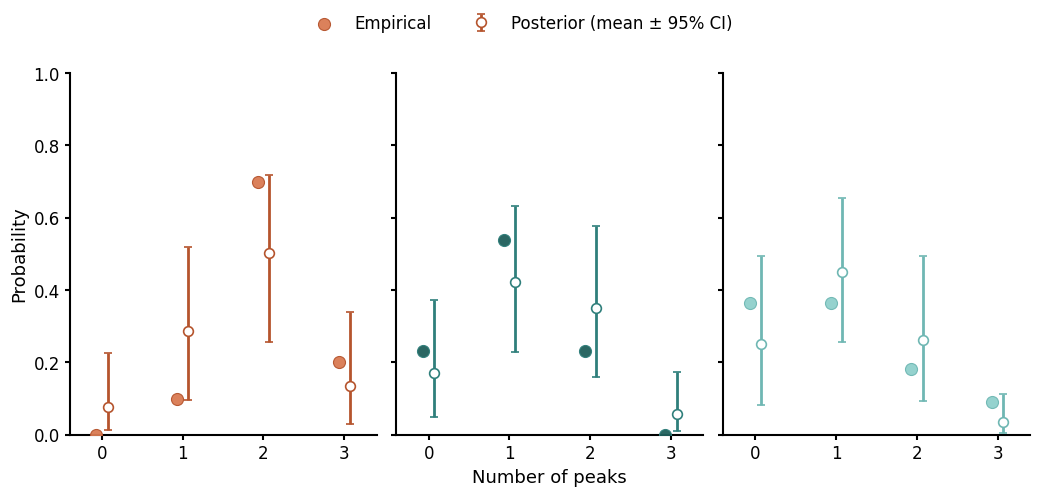

In [15]:
## Plot empirical category probabilities against posterior (mean ± 95% CI)
fig, axes = plt.subplots(1, 3, figsize=(10.5, 5), sharey=True)

x_offset = 0.07  # small dodge so empirical and posterior don't overlap

for ax, lek in zip(axes, lek_labels_ordered):
    empirical_data = peak_proportions[peak_proportions['lek_id'] == lek].sort_values('n_peaks')
    model_posteriors = post[post['lek_id'] == lek].sort_values('n_peaks')

    col_fill = fill_cols[str(lek)]
    col_point = point_cols[str(lek)]

    # Empirical proportions (filled markers)
    ax.scatter(empirical_data['n_peaks'] - x_offset, empirical_data['prop'], s=75,
               facecolor=col_point, edgecolor=col_fill,
               linewidth=0.8, alpha=0.95, zorder=4,
               label="Empirical" if ax is axes[0] else None)

    # Posterior mean + 95% CI (hollow markers + error bars)
    ax.errorbar(model_posteriors['n_peaks'] + x_offset, model_posteriors['mean'],
                yerr=[model_posteriors['mean'] - model_posteriors['lo'], model_posteriors['hi'] - model_posteriors['mean']],
                fmt='o', markersize=7, mfc='white', mec=col_fill, mew=1.2,
                color=col_fill, ecolor=col_fill, elinewidth=2, capsize=3, zorder=3,
                label="Posterior (mean ± 95% CI)" if ax is axes[0] else None)

    ax.set_xticks(peak_categories)
    ax.set_xlim(-0.4, peak_categories.max() + 0.4)
    ax.set_ylim(0, 1)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.5)
    ax.spines['bottom'].set_linewidth(1.5)
    ax.tick_params(axis='both', which='major', labelsize=12, width=1.5)

axes[1].set_xlabel('Number of peaks', fontsize=13)
axes[0].set_ylabel('Probability', fontsize=13)

# Add legend
legend_elements = [Line2D([0], [0], marker='o', color='black', markerfacecolor='black', markersize=7, linestyle='None', label='Empirical'),
                   Line2D([0], [0], marker='o', color='black', markerfacecolor='white', markeredgewidth=1.2, markersize=7, linestyle='-', linewidth=2, label='Posterior (mean ± 95% CI)')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, frameon=False, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig(out_dir/'npeaks_structure.png', dpi=300, bbox_inches='tight')

In [ ]:
## Ready dataframe to model the curvature of peaks on the pcf curves
# For curvature, we only keep actual peak rows (non-missing peak_curvature)
peaks_only = peaks.dropna(subset=['peak_curvature']).copy()

# Attach curve-level metadata (site_id, time_id, n_points, n_peaks) to each peak row
peaks_only = peaks_only.merge(
    n_peaks_df[['lek_id', 'date', 'site_id', 'time_id'] + (['n_points'] if 'n_points' in n_peaks_df.columns else []) + ['n_peaks'],
    on=['lek_id', 'date'],
    how='left'
)

curvature_df = peaks_only.sort_values(['lek_id', 'date', 'r_peak']).copy()
curvature_df['peak_num'] = curvature_df.groupby(['lek_id', 'date']).cumcount() + 1

curvature_df['log_curvature'] = np.log(curvature_df['peak_curvature'])
curvature_df = curvature_df[['lek_id', 'site_id', 'date', 'time_id', 'n_points', 'n_peaks', 'peak_num', 
                             'r_peak', 's_peak', 'peak_prominence', 'peak_curvature', 'log_curvature']].reset_index(drop=True)

In [ ]:
curvature_df = curvature_df.merge(curves, on=['lek_id', 'date'], how='left')

## Standardize peak_num for nicer sampling / interpretation
curvature_df['peak_num_z'] = (curvature_df['peak_num'] - curvature_df['peak_num'].mean()) / curvature_df['peak_num'].std(ddof=0)

In [ ]:
curvature_mod = """
data {
  int<lower=1> n_points;
  int<lower=1> n_sites;
  int<lower=1> n_pcf_curves;

  array[n_points] int<lower=1, upper=n_sites> site_id;
  array[n_points] int<lower=1, upper=n_pcf_curves> curve_id;

  vector[n_points] peak_num_z;                    // standardized peak number
  vector[n_points] log_curvature;                 // log(peak_curvature)
}

parameters {
  real alpha;                               // grand intercept (log scale)

  // Site-level fixed intercepts and optional slope deviations
  vector[n_sites] site_int_raw;
  real<lower=0> sigma_site_int;

  real beta_peak;                           // global effect of peak number (expect < 0)

  vector[n_sites] site_slope_raw;                 // site-specific slope deviations (optional)
  real<lower=0> sigma_site_slope;           // shrinkage for site slope deviations

  // Curve-level random intercepts and optional random slopes
  vector[n_pcf_curves] curve_int_raw;
  real<lower=0> sigma_curve_int;

  // Observation noise on log scale
  real<lower=0> sigma;
}

transformed parameters {
  vector[n_sites] site_int = site_int_raw * sigma_site_int;

  // site-specific slopes around global beta_peak
  vector[n_sites] site_slope = beta_peak + site_slope_raw * sigma_site_slope;
}

model {
  // Priors (weakly informative)
  alpha ~ normal(0, 5);                     // wide on log scale

  site_int_raw ~ normal(0, 1);
  sigma_site_int ~ normal(0, 2);

  beta_peak ~ normal(0, 1);                 // with peak_num_z, slope ~ O(1)

  site_slope_raw ~ normal(0, 1);
  sigma_site_slope ~ normal(0, 1);

  sigma_curve_int ~ normal(0, 2);

  sigma ~ normal(0, 1);

  // Likelihood
  for (n in 1:n_points) {
    real mu = alpha + site_int[site_id[n]] + beta_peak * peak_num_z[n];

    log_curvature[n] ~ normal(mu, sigma);
  }
}

generated quantities {
  real diff_int_2_1 = site_int[2] - site_int[1];
  real diff_int_3_1 = site_int[3] - site_int[1];
  real diff_int_3_2 = site_int[3] - site_int[2];

  // Geometric-mean ratios for curvature (multiplicative)
  real gmr_int_2_1 = exp(diff_int_2_1);
  real gmr_int_3_1 = exp(diff_int_3_1);
  real gmr_int_3_2 = exp(diff_int_3_2);

  // Peak-number slope per site (on standardized scale)
  // Interpretable as multiplicative change per +1 SD in peak_num
  vector[S] slope_mult;
  for (s in 1:n_sites) slope_mult[s] = exp(site_slope[s]);
}
"""

data_curvature = {
    'n_points': len(curvature_df),
    'n_sites': int(curvature_df['site_id'].nunique()),
    'n_pcf_curves': int(curvature_df['curve_id'].nunique()),
    'site_id': curvature_df['site_id'].astype(int).to_numpy(),
    'curve_id': curvature_df['curve_id'].astype(int).to_numpy(),
    'peak_num_z': curvature_df['peak_num_z'].astype(float).to_numpy(),
    'log_curvature': curvature_df['log_curvature'].astype(float).to_numpy(),
}

posterior = stan.build(curvature_mod, data=data_curvature)
fit = posterior.sample(num_chains=4, num_warmup=1000, num_samples=1000)